# Email Spam Classification Model

In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score

In [174]:
data = pd.read_csv("spam.csv",encoding="latin-1")  #By default UTF-8 characters, use Latin-1 characters for this dataset

In [175]:
data.head()

,class,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [176]:
data.shape

(5572, 5)

In [177]:
data.isnull().sum()

class            0
message          0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [178]:
data.drop_duplicates(inplace=True)

In [179]:
data['class']=data['class'].replace( ['ham','spam'],['Not_Spam','Spam'] )

In [180]:
data.head()

,class,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Not_Spam,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,Not_Spam,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,Not_Spam,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,Not_Spam,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [181]:
data.columns

Index(['class', 'message', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [182]:
data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [183]:
data.head()

,class,message
0,Not_Spam,"Go until jurong point, crazy.. Available only ..."
1,Not_Spam,Ok lar... Joking wif u oni...
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,Not_Spam,U dun say so early hor... U c already then say...
4,Not_Spam,"Nah I don't think he goes to usf, he lives aro..."


In [184]:
data.columns

Index(['class', 'message'], dtype='object')

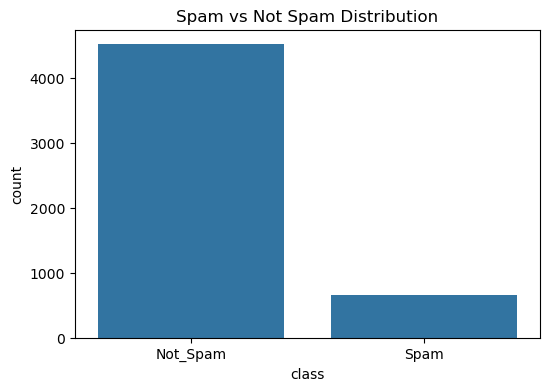

In [185]:
#visualize: How many spam and How many not spam
plt.figure(figsize=(6,4))
sns.countplot(x=data['class'])
plt.title("Spam vs Not Spam Distribution")
plt.show()

In [186]:
# In target variable(Category), spam:1 and not_spam:0 
data['class']=data['class'].map( {"Not_Spam":0,"Spam":1} )

In [187]:
data.head()

,class,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [188]:
x=data['message']
y=data['class']

# Vectorization

In [189]:
'''Imports the tool used to convert text into numbers.
Creates a CountVectorizer object:
stop_words='english' → removes common words like the, is, and, of '''

cv=CountVectorizer(stop_words='english')

In [190]:
x=cv.fit_transform(x) #Convert text to numerical data 

In [191]:
x

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 39585 stored elements and shape (5169, 8404)>

# Modeling phase (Machine Learning)

In [192]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [193]:
x_train.shape

(4135, 8404)

In [194]:
y_train.shape

(4135,)

## Multinomial Naive Bayes

In [195]:
model=MultinomialNB()
model.fit(x_train,y_train)

MultinomialNB()

In [196]:
result = model.score(x_test,y_test)

In [197]:
result=result*100
result

97.58220502901354

In [198]:
#Predict whether an email/a message is spam or not
msg="You won 100 dollars"
data=[msg]

vect = cv.transform(data).toarray()
result = model.predict(vect)

if result==1:
    print("Spam")
else:
    print("Not Spam")

Spam


In [199]:
#Evaluation Metrics
y_pred=model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred) )
print("Precision: ",precision_score(y_test, y_pred) )

cm = confusion_matrix(y_test,y_pred)
cm

Accuracy:  0.9758220502901354
Precision:  0.9


array([[874,  15],
       [ 10, 135]])

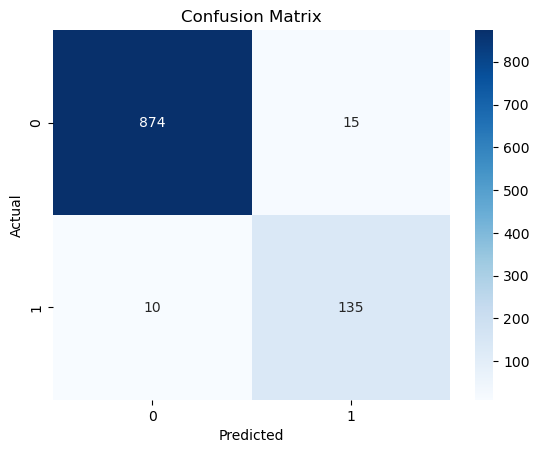

In [200]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Other ML models

In [201]:
# 2. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
print("Logistic Regression Accuracy(score):", accuracy_score(y_test, y_pred_lr))


# 3. Support Vector Machine (SVM)
svm = SVC(kernel='linear')  # linear kernel is good for text classification
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
print("SVM Accuracy(score):", accuracy_score(y_test, y_pred_svm))


Logistic Regression Accuracy(score): 0.97678916827853
SVM Accuracy(score): 0.9806576402321083


                     Accuracy  Precision    Recall
Multinomial NB       0.975822   0.900000  0.931034
Logistic Regression  0.976789   0.991870  0.841379
SVM                  0.980658   0.984496  0.875862


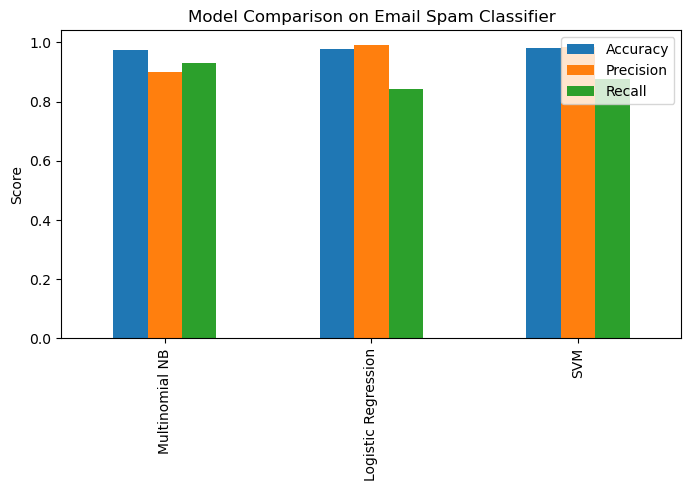

In [202]:
# Models and their predictions
models = ['Multinomial NB', 'Logistic Regression', 'SVM']
y_preds = [y_pred, y_pred_lr, y_pred_svm]

# Calculate metrics
metrics = []
for y_pred in y_preds:
    metrics.append( [accuracy_score(y_test, y_pred),precision_score(y_test, y_pred),recall_score(y_test, y_pred)] )

metrics_df = pd.DataFrame(metrics, columns=['Accuracy', 'Precision', 'Recall'], index=models)
print(metrics_df)

# Plot comparison
metrics_df.plot(kind='bar', figsize=(8,4))
plt.title('Model Comparison on Email Spam Classifier')
plt.ylabel('Score')
plt.show()

In [203]:
import pickle

pickle.dump(model,open("spam.pkl","wb"))
pickle.dump(cv,open("vectorizer.pkl","wb"))